# Bonus Task — 2D Gaussian Bayes Classifier (3 Classes)

This notebook implements the bonus task using **two measurements** \((x,y)\) and **three classes** (A, C, T).  
Under zero–one loss, the Bayes rule is:
$$
\hat{k}(x,y)
= \arg\max_{k\in\{A,C,T\}}
p_K(k)\,\mathcal{N}\!\big([x,y]^{\top}\mid \mu_k,\Sigma_k\big).
$$

Expected output:
- Classification error of the optimal Bayes strategy on the provided image set,
- Visualization of the classification of input images (images per class and a 2D scatter with model ellipses).

## Load data

In [223]:
import numpy as np
import matplotlib.pyplot as plt

D1 = {'Mean': np.array([151.61, 1154.01]),
      'Prior': 0.4166666666666667,
      'Cov': np.array([[2048960.78575758, 169829.10494949],
                       [ 169829.10494949, 482516.97969697]])}

D2 = {'Mean': np.array([-2055.76666667,    54.3]),
      'Prior': 0.25,
      'Cov': np.array([[307539.97853107,  -2813.69830508],
                       [ -2813.69830508, 485574.58644068]])}

D3 = {'Mean': np.array([  492.7125, -2353.1125]),
      'Prior': 0.3333333333333333,
      'Cov': np.array([[968935.42262658,  12248.03053797],
                       [ 12248.03053797, 407017.16439873]])}

data = np.load("data_33rpz_bayes_bonus.npz", allow_pickle=True)
alphabet = data["alphabet"]
images_test = data["images"]
labels_test = data["labels"]
print(images_test.shape, labels_test.shape)

alphabet = ['A', 'C', 'T']
# spent almost 2h debugging until I realised that alphabet was just 1 string 'ACT',
# not 'A', 'C', 'T', so I had enough and just redefined it

print("alphabet normalized:", alphabet)  # sanity: ['A','C','T']

(10, 10, 240) (240,)
alphabet normalized: ['A', 'C', 'T']


## Feature extraction $x$ = left - right, $y$ = upper - lower

In [224]:
def compute_measurement_xy(imgs):
    """
    XY = compute_measurement_xy(imgs)

    Compute two measurements on images:
      x = sum(left half)  - sum(right half)
      y = sum(upper half) - sum(lower half)

    :param imgs:  set of images, (h, w, n)
    :return:      measurements, (n, 2) as [[x1,y1], [x2,y2], ...]
    """
    assert len(imgs.shape) == 3
    h, w, n = imgs.shape
    mid_w, mid_h = w // 2, h // 2

    left  = imgs[:, :mid_w, :].sum(axis=(0, 1), dtype=np.int64)
    right = imgs[:,  mid_w:, :].sum(axis=(0, 1), dtype=np.int64)
    up    = imgs[:mid_h, :, :].sum(axis=(0, 1), dtype=np.int64)
    down  = imgs[ mid_h:, :, :].sum(axis=(0, 1), dtype=np.int64)

    x = left - right
    y = up   - down
    XY = np.stack([x, y], axis=1).astype(np.float64)
    assert XY.shape == (n, 2)
    return XY

XY = compute_measurement_xy(images_test)
XY[:10]

array([[  671., -1991.],
       [-1974.,  -140.],
       [  720., -1964.],
       [ 1300., -2694.],
       [  650., -2392.],
       [-1484.,   480.],
       [-1463., -3487.],
       [-1065.,   425.],
       [ 1954.,  1276.],
       [ 1426., -2162.]])

## Multivariate Gaussian log-PDF and Bayes Risk

In [225]:
def mvn_logpdf_2d(X, mean, cov):
    """
    log f_x(x) for 2D Gaussian:
      -0.5 * [ 2*log(2π) + log|Σ| + (x-μ)^T Σ^{-1} (x-μ) ]
    :param X:    (n,2)
    :param mean: (2,)
    :param cov:  (2,2)
    :return:     (n,) log-pdf values
    """
    X = np.atleast_2d(X).astype(float)
    mu = np.asarray(mean, dtype=float).reshape(2,)
    S  = np.asarray(cov,  dtype=float).reshape(2,2)

    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        raise ValueError("Covariance not positive definite.")
    inv = np.linalg.inv(S)
    diff = X - mu
    quad = np.einsum('ni,ij,nj->n', diff, inv, diff)
    return -0.5 * (2*np.log(2*np.pi) + logdet + quad)


# ========= Bayes risk (continuous, 3 classes) =========
def bayes_risk_3normal(D1, D2, D3, XY):
    """
    R = bayes_risk_3normal(D1, D2, D3, XY)

    Compute empirical Bayes risk under 0-1 loss for the optimal Bayes rule:
      R = mean_x [ 1 - max_k p(k|x) ]
    Also returns the optimal Bayes decisions for the given samples.

    Each Dk is a dict with:
      Dk['Mean'] (2,), Dk['Cov'] (2,2), Dk['Prior'] (float)

    :param XY: (n,2) measurements
    :return:
      R_emp        - python float
      labels_hat   - (n,) np.int32, argmax_k p(k|x)
    """
    lp1 = np.log(D1['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D1['Mean'], D1['Cov'])
    lp2 = np.log(D2['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D2['Mean'], D2['Cov'])
    lp3 = np.log(D3['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D3['Mean'], D3['Cov'])

    L = np.column_stack([lp1, lp2, lp3])
    m = L.max(axis=1, keepdims=True)
    exp_shift = np.exp(L - m)
    post = exp_shift / (exp_shift.sum(axis=1, keepdims=True) + 1e-15)

    labels_hat = np.argmax(L, axis=1).astype(np.int32)
    R_emp = float(np.mean(1.0 - post.max(axis=1)))
    return R_emp, labels_hat

## Normal Classifier and Classification Error

In [226]:
# ========= classify (continuous, 3 classes) =========
def classify_3normal(D1, D2, D3, XY):
    """
    labels = classify_3normal(D1, D2, D3, XY)

    Optimal Bayes classifier for 3 Gaussians under 0-1 loss:
      label = argmax_k p(K=k) * N([x,y]|μ_k, Σ_k)
    :return: (n,) np.int32 labels in {0,1,2}
    """
    lp1 = np.log(D1['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D1['Mean'], D1['Cov'])
    lp2 = np.log(D2['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D2['Mean'], D2['Cov'])
    lp3 = np.log(D3['Prior'] + 1e-300) + mvn_logpdf_2d(XY, D3['Mean'], D3['Cov'])
    L = np.column_stack([lp1, lp2, lp3])
    return np.argmax(L, axis=1).astype(np.int32)


# ========= classification error (works for 3 classes) =========
def classification_error(predictions, labels):
    """
    error = classification_error(predictions, labels)
    :param predictions: (n,) int labels in {0,1,2}
    :param labels:      (n,) int labels in {0,1,2}
    :return:            float in [0,1]
    """
    p = np.asarray(predictions).reshape(-1)
    l = np.asarray(labels).reshape(-1)
    assert p.shape == l.shape, (p.shape, l.shape)
    return float(np.mean(p != l))

## Plot the 3 Classes Obtained and (optionally) Save Them

In [227]:
def montage(images):
    """
    Show images in grid.

    :param images:  np.array (h, w, n)
    :return:        canvas as np.array (for saving)
    """
    h, w, count = np.shape(images)
    if count == 0:
        return np.zeros((h, w), dtype=images.dtype)
    h_sq = int(np.ceil(np.sqrt(count)))
    w_sq = h_sq
    im_matrix = np.zeros((h_sq * h, w_sq * w), dtype=images.dtype)

    image_id = 0
    for k in range(w_sq):
        for j in range(h_sq):
            if image_id >= count:
                break
            slice_w = j * h
            slice_h = k * w
            im_matrix[slice_h:slice_h + w, slice_w:slice_w + h] = images[:, :, image_id]
            image_id += 1
    return im_matrix


def show_and_save_images_per_predicted_class(images, labels_hat, class_names=('A','C','T'), save=True):
    """
    Show a 1x3 figure with montages for predicted classes 0/1/2.
    Saves individual PNGs (Predicted_<name>_nK.png) iff save=True.
    Does NOT save the combined panel image.
    """
    class_names = list(class_names)
    assert len(class_names) == 3, "expects three classes"

    canvases, counts, filenames = [], [], []
    for k, name in enumerate(class_names):
        idx = np.where(labels_hat == k)[0]
        ims = images[:, :, idx] if idx.size else images[:, :, :0]
        canvas = montage(ims)
        canvases.append(canvas)
        counts.append(idx.size)
        if save:
            fname = f"Predicted_{name}_n{idx.size}.png"
            plt.imsave(fname, canvas, cmap='gray')
            filenames.append(fname)
            print("saved:", fname)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, canvas, name, n in zip(axes, canvases, class_names, counts):
        ax.imshow(canvas, cmap='gray')
        ax.set_title(f"Predicted: {name}  (n={n})")
        ax.axis('off')
    fig.suptitle("Images grouped by predicted class", y=0.98)
    plt.tight_layout()
    plt.show()

## Run Everything

Empirical Bayes risk: 0.051606726050523785
Classification error: 0.075
saved: Predicted_A_n99.png
saved: Predicted_C_n63.png
saved: Predicted_T_n78.png


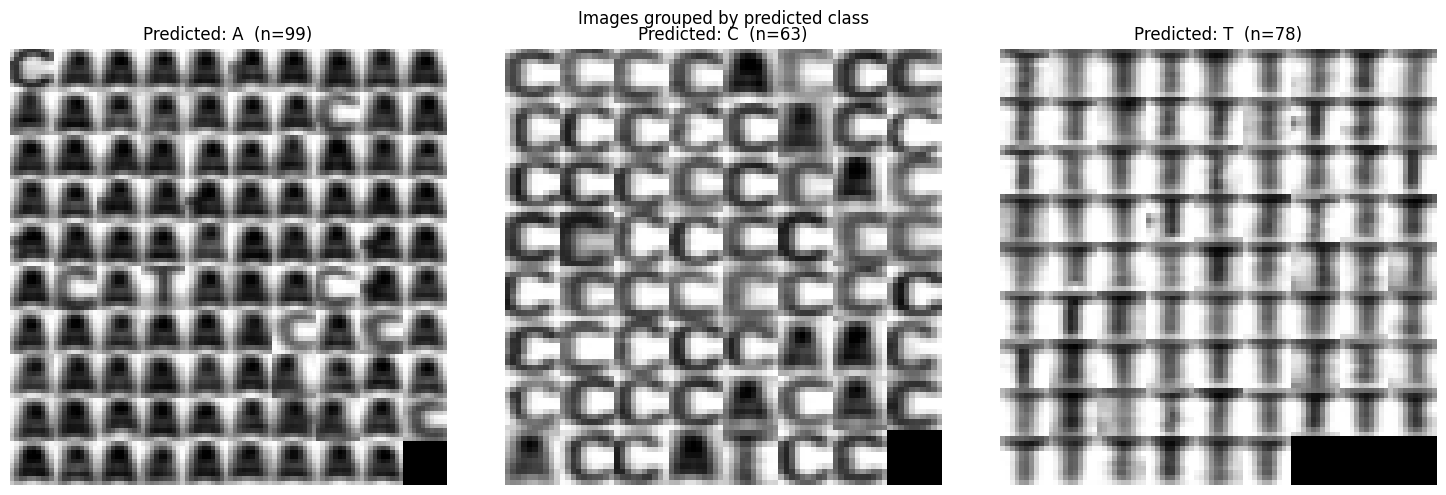

In [228]:
XY = compute_measurement_xy(images_test)

R_emp, labels_hat = bayes_risk_3normal(D1, D2, D3, XY)
print("Empirical Bayes risk:", R_emp)

err = classification_error(labels_hat, labels_test)
print("Classification error:", err)

show_and_save_images_per_predicted_class(images_test, labels_hat, alphabet, save=True)
